# Tweet Classification using RoBERTa

This notebook implements a text classifier to classify tweets into two classes:
- Class '1': If the tweet mentions the tweeter doing a moderate to high physical activity or how they feel about the mentioned activity
- Class '0': If the tweet does not refer to the tweeter doing a moderate to high physical activity

In [26]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from transformers import RobertaTokenizer, RobertaForSequenceClassification
# Import functions from main.py
from main import (
    preprocess_text, 
    load_data, 
    run_classifier, 
    analyze_class_distribution,
    save_model,
    load_model,
    set_seed
)

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Explore the Data

In [28]:
# File paths
training_tweets_path = 'WN25_data/WN25_PA_training_tweets.txt'
training_labels_path = 'WN25_data/WN25_PA_training_labels.txt'
test_tweets_path = 'WN25_data/WN25_PA_test_tweets.txt'
output_path = 'predictions.csv'

# Read the files
training_tweets = pd.read_csv(training_tweets_path, encoding='latin-1')
training_labels = pd.read_csv(training_labels_path, encoding='latin-1')
test_tweets = pd.read_csv(test_tweets_path, encoding='latin-1')

# Display the first few rows to check the format
print("Training tweets shape:", training_tweets.shape)
print(training_tweets.head())

print("\nTraining labels shape:", training_labels.shape)
print(training_labels.head())

print("\nTest tweets shape:", test_tweets.shape)
print(test_tweets.head())

Training tweets shape: (4000, 3)
   TweetID  TimeOfDay                                              Tweet
0     1001         17  The Bulldogs have been selected to finish 4th ...
1     1002         22  Played disc golf. Got a tattoo. Heading to Det...
2     1003         16  Sunday big football game I'm gunna gather all ...
3     1004         20  Despite my resolution to be nicer to Scooter t...
4     1005         18  Reassigned by Michigan Runner to shoot Goodlif...

Training labels shape: (4000, 2)
   TweetID  Label
0     1001      0
1     1002      1
2     1003      0
3     1004      0
4     1005      0

Test tweets shape: (1000, 3)
   TweetID  TimeOfDay                                              Tweet
0     5001         19  MI Playmakers - Green 46, FABE 24, 5th Grade -...
1     5002         22  I biked 2.46 mi with @mapmyride. Check out my ...
2     5003         20  @Jacob_Nash yes I do, it's just I said hi Best...
3     5004         20  Countless hours of house hunting has taugh

## 2. Data Analysis and Preprocessing

2025-03-13 21:49:49,307 - INFO - Class distribution:
2025-03-13 21:49:49,308 - INFO - Class 0: 2712 samples (67.80%)
2025-03-13 21:49:49,308 - INFO - Class 1: 1288 samples (32.20%)
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


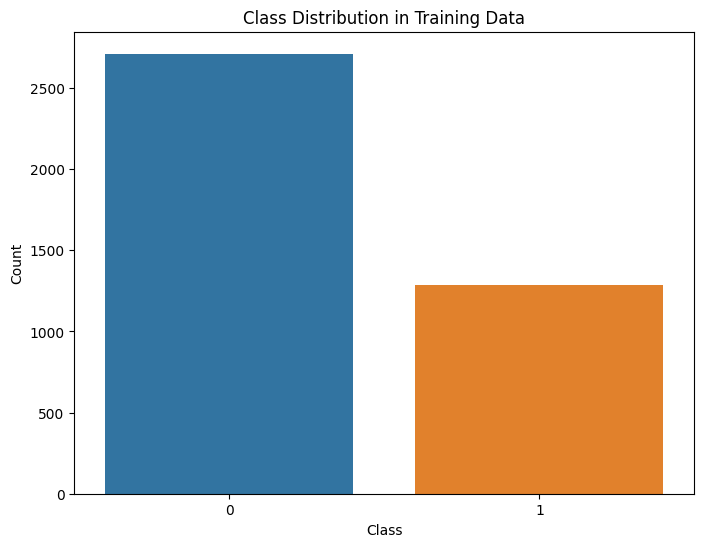

In [29]:
# Merge training tweets with their labels
train_data = pd.merge(training_tweets, training_labels, on='TweetID')

# Analyze class distribution
class_counts = analyze_class_distribution(train_data['Label'])

# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=train_data)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [30]:
# Preprocess a sample tweet to check the preprocessing function
sample_tweet = training_tweets.iloc[1097]['Tweet']
print("Original tweet:")
print(sample_tweet)
print("\nPreprocessed tweet:")
print(preprocess_text(sample_tweet))

Original tweet:
Niggas run they mouth like some bitches, but scared to say it to my face! Niggas is really hoes no of daysÕæ_Õ_¿

Preprocessed tweet:
niggas run they mouth like some bitches, but scared to say it to my face! niggas is really hoes no of days


/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

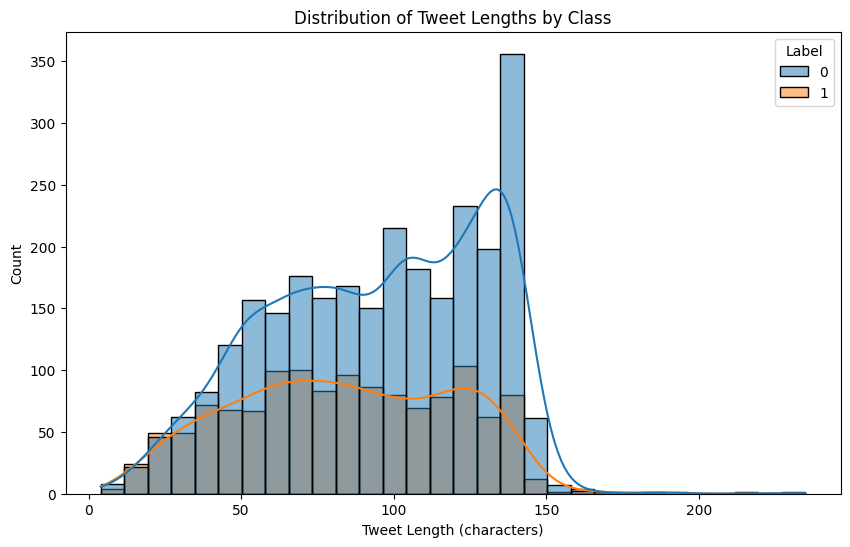

In [31]:
# Analyze tweet lengths
train_data['tweet_length'] = train_data['Tweet'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=train_data, x='tweet_length', hue='Label', bins=30, kde=True)
plt.title('Distribution of Tweet Lengths by Class')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Count')
plt.show()

## 3. Prepare Data for DistilBERT

In [32]:
train_data, test_df = load_data(training_tweets_path, training_labels_path, test_tweets_path)

# Check class distribution in the entire training dataset
print("Training dataset class distribution:")
analyze_class_distribution(train_data['Label'])

2025-03-13 21:49:49,544 - INFO - Total dataset size: 4000
2025-03-13 21:49:49,559 - INFO - Class distribution:
2025-03-13 21:49:49,559 - INFO - Class 0: 2712 samples (67.80%)
2025-03-13 21:49:49,559 - INFO - Class 1: 1288 samples (32.20%)


Training dataset class distribution:


Label
0    2712
1    1288
Name: count, dtype: int64

## 4. Train and Evaluate DistilBERT Model

In [33]:
# Set seed for reproducibility
set_seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [34]:
# Run the classifier
model, best_val_f1, submission = run_classifier(
    training_tweets_path=training_tweets_path,
    training_labels_path=training_labels_path,
    test_tweets_path=test_tweets_path,
    output_path=output_path,
    batch_size=16,
    epochs=5
)

2025-03-13 21:49:49,605 - INFO - Using device: cpu
2025-03-13 21:49:49,658 - INFO - Total dataset size: 4000
2025-03-13 21:49:49,762 - INFO - Starting fold 1/5
2025-03-13 21:49:49,763 - INFO - Training set size: 3200
2025-03-13 21:49:49,763 - INFO - Validation set size: 800
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
2025-03-13 21:49:50,018 - INFO - Model has 124,647,170 total parameters
2025-03-13 21:49:50,019 - INFO - Frozen 116,967,168 parameters (93.8%)
2025-03-13 21:49:50,019 - INFO - Trainable 7,680,002 parameters (6.2%)
2025-03-13 21:49:50,019 - INFO - Using warmup strategy with 100 warmup steps (10% of total steps)
Epochs:   0%|          | 0/5 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [14]:
# Initialize the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Save the model and tokenizer
save_model(model, tokenizer, 'saved_roberta_model')

2025-03-13 21:02:10,086 - INFO - Model saved to saved_roberta_model


In [53]:
from simple_test import test_sentence
sentence = "Do you want to go take a nlp class next semester?"
test_sentence(sentence)
sentence = "I'm not going to gym today"
test_sentence(sentence)

2025-03-13 23:28:36,203 - INFO - Model loaded from saved_roberta_model


Using device: cpu
Loading model from saved_roberta_model...
Model loaded successfully!
Original text: Do you want to go take a nlp class next semester?
Processed text: do you want to go take a nlp class next semester?


2025-03-13 23:28:37,305 - INFO - Model loaded from saved_roberta_model



------------------------------------------------------------
PREDICTION: Not mentioned doing physical activity (Class 0)
CONFIDENCE: 0.9098
CLASS PROBABILITIES:
  - Not Mentioned Physical Activity: 0.9098
  - Mentioned Physical Activity: 0.0902
------------------------------------------------------------
Using device: cpu
Loading model from saved_roberta_model...
Model loaded successfully!
Original text: I'm not going to gym today
Processed text: i am not going to gym today

------------------------------------------------------------
PREDICTION: Mentioned doing physical activity (Class 1)
CONFIDENCE: 0.9947
CLASS PROBABILITIES:
  - Not Mentioned Physical Activity: 0.0053
  - Mentioned Physical Activity: 0.9947
------------------------------------------------------------


{'original_text': "I'm not going to gym today",
 'processed_text': 'i am not going to gym today',
 'prediction': 1,
 'prediction_label': 'Mentioned doing physical activity',
 'confidence': 0.9946731925010681,
 'probabilities': {'class_0': 0.005326864309608936,
  'class_1': 0.9946731925010681}}

## 5. Analyze Predictions

In [15]:
# Display the first few predictions
print(submission.head(10))

# Analyze prediction distribution
prediction_counts = submission['Label'].value_counts()
print("\nPrediction distribution:")
for label, count in prediction_counts.items():
    percentage = (count / len(submission)) * 100
    print(f"Class {label}: {count} samples ({percentage:.2f}%)")

   TweetID  Label
0     5001      0
1     5002      1
2     5003      0
3     5004      0
4     5005      0
5     5006      1
6     5007      1
7     5008      0
8     5009      0
9     5010      0

Prediction distribution:
Class 0: 663 samples (66.30%)
Class 1: 337 samples (33.70%)


/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


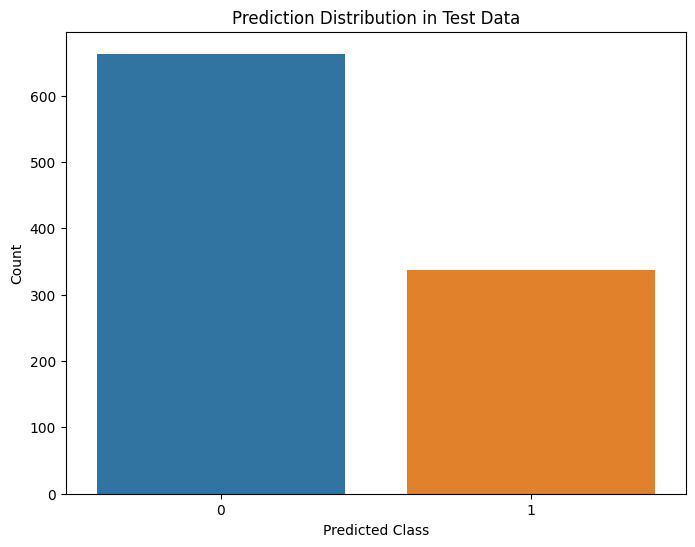

In [ ]:
# Visualize prediction distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=submission)
plt.title('Prediction Distribution in Test Data')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.show()